In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [8]:
housing=fetch_california_housing()
data=pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"]=housing.target

In [10]:
X=data[['AveRooms']].values
y=data['Price'].values

In [12]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [30]:
w = 0
b = 0
learning_rate = 0.01
epochs = 1000
cost_history = []
n = len(X_train_scaled)

for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
   
    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)
   
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
       
        print(f"Epoch{i}, cost = {cost:.4f}")

y_pred_gd = w * X_train_scaled.flatten() + b

Epoch0, cost = 2.8149
Epoch100, cost = 0.9414
Epoch200, cost = 0.6904
Epoch300, cost = 0.6568
Epoch400, cost = 0.6523
Epoch500, cost = 0.6517
Epoch600, cost = 0.6516
Epoch700, cost = 0.6516
Epoch800, cost = 0.6516
Epoch900, cost = 0.6516


In [24]:
X_train_ne=np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne=np.c_[np.ones((len(X_test),1)),X_test]
theta= np.linalg.inv(X_train_ne.T@X_train_ne)@X_train_ne.T@y_train
y_pred_ne=X_test_ne@theta

In [26]:
print("\nNormal Equation")
print("-----------------")
print("Intercept:",theta[0])
print("Slope:",theta[1])
print("MSE:", mean_squared_error(y_test,y_pred_ne))
print("R2 Score:",r2_score(y_test,y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


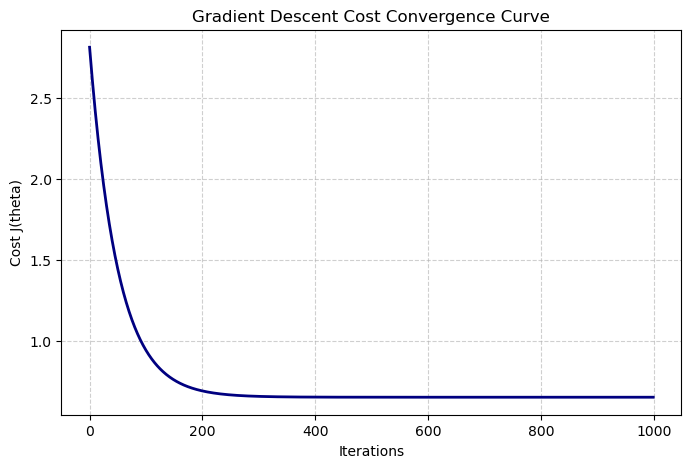

In [32]:
plt.figure(figsize=(8,5))
plt.plot(cost_history,color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.ylabel('Cost J(theta)')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()

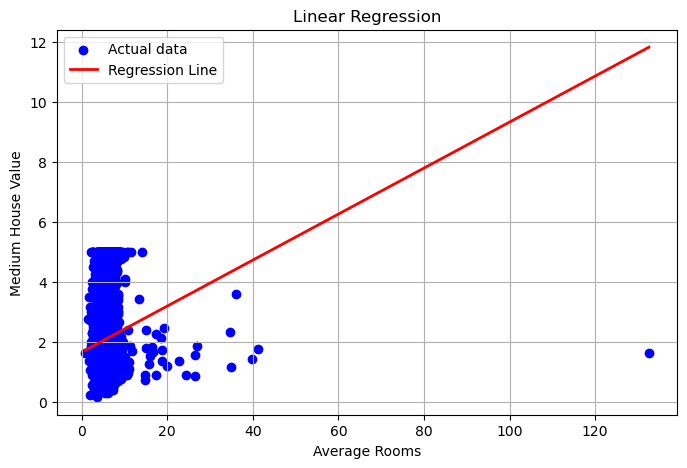

In [34]:
index=np.argsort(X_test.flatten())
plt.figure(figsize=(8,5))
plt.scatter(X_test,y_test,color='blue',label='Actual data')
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='red',
    linewidth=2,
    label='Regression Line'
)
plt.title("Linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Medium House Value")
plt.legend()
plt.grid(True)
plt.show()